In [1]:
import requests
import pandas as pd
import numpy as np
import geopandas
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import time

import geopandas as gpd
import shapely
from shapely.ops import snap, unary_union
from shapely.geometry.polygon import Polygon
from shapely.geometry.multipolygon import MultiPolygon
import plotly.express as px

In [4]:
#Исследование рынка заведений общественного питания Москвы,для этого будем использовать api портала откртых данных

In [2]:
api_key='f27ba15c-cb62-4e67-b2fe-f5e37054451c'
session=requests.Session()

In [3]:
def get_request(url:str,params:dict=None):
    if params:
       return session.get(url, params=params).json()
    else:
        return  session.get(url).json()

In [4]:
#узнаем к какой категории относится общественное питание на этом сервере
url='https://apidata.mos.ru/v1/categories?api_key=f27ba15c-cb62-4e67-b2fe-f5e37054451c'

params={
    '$inlinecount':True #чтобы получить общее кол-во записей 
}

data=get_request(url,params)

In [5]:
#из массива категорий найдем данные для Общественного питания
catering=[]
for item in data['categories']:
    if item['Name']== 'Общественное питание':
        catering=item
        break
#нам вернулся словарь по ключу Datasets лежит список наборов данных относящихся к категории и структура хранения данных

In [6]:
#проходимся по каждому департаменту и заносим значения в словарь,для дальнейшего Датасета
results={}

for i in catering['Datasets']:
    
    batch_size=1000 #максимальный размер массивы который можем получить за 1 запрос
    
    url=f'https://apidata.mos.ru/v1/datasets/{i}/count?api_key=f27ba15c-cb62-4e67-b2fe-f5e37054451c'
    count=get_request(url) #кол-во элементов в i категории
    
    get_count=min(count,batch_size)
    
    if(get_count>0):
        
        for j in range(0,count,get_count): #так как за раз мы не можем считать больше 1000 данных то разделим это дейсвтие на несколько иттераций
        
            params={
                    '$skip': j,
                    '$top': batch_size
                }
        
            url1=f'https://apidata.mos.ru/v1/datasets/{i}/rows?api_key=f27ba15c-cb62-4e67-b2fe-f5e37054451c'#получим данные о заведениях в i департаменте
            response=get_request(url1,params)
    
            for item in  response:
                for key, value in item['Cells'].items():
                    if key not in results.keys():
                        results[key]=[value]
                    else:
                        results[key].append(value)

        
        time.sleep(3)
        
DF=pd.DataFrame(results)


In [7]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39314 entries, 0 to 39313
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   global_id         39314 non-null  int64 
 1   ID                39314 non-null  object
 2   Name              39314 non-null  object
 3   IsNetObject       39314 non-null  object
 4   OperatingCompany  39314 non-null  object
 5   TypeObject        39314 non-null  object
 6   AdmArea           39314 non-null  object
 7   District          39314 non-null  object
 8   Address           39314 non-null  object
 9   PublicPhone       39314 non-null  object
 10  SeatsCount        39314 non-null  int64 
 11  SocialPrivileges  39314 non-null  object
 12  Longitude_WGS84   39314 non-null  object
 13  Latitude_WGS84    39314 non-null  object
 14  geoData           39314 non-null  object
dtypes: int64(2), object(13)
memory usage: 4.5+ MB


In [8]:
#преобразуем полученный DF
#видим что geodata повторяет данные 2х столбцов Longitude_WGS84 Latitude_WGS84
#столбцы IsNetObject и SocialPrivileges принимают 2 значения True и False тогда преобразуем их в тип bool
#1)удалим данные geodata так как есть данные о широте и долготе 
#2)преобразуем данные которые лежат в широте и долготе в объект shapely.geometry.Point для дальнейшего нанесения на карту

DF.drop(columns={'geoData'},inplace=True)
series=[]
phones=[]
DF['geoData'] = gpd.points_from_xy(DF['Longitude_WGS84'], DF['Latitude_WGS84'])
DF.drop(columns={'Longitude_WGS84','Latitude_WGS84'},inplace=True)
DF.drop(columns='OperatingCompany',inplace=True)

In [336]:
DF

,global_id,ID,Name,IsNetObject,TypeObject,AdmArea,District,Address,PublicPhone,SeatsCount,SocialPrivileges,geoData
0,637377571,000021304,рахимкулова т.х.,False,буфет,Северо-Восточный административный округ,Бибирево,Алтуфьевское шоссе дом 102Б,"[{'global_id': 48646, 'is_deleted': 0, 'Public...",20,False,POINT (37.59132 55.90406)
1,637379209,000021065,буфет при астраханских банях,False,буфет,Центральный административный округ,Мещанский,Астраханский переулок дом 5/9,"[{'global_id': 48694, 'is_deleted': 0, 'Public...",3,False,POINT (37.63958 55.77888)
2,637379268,000021483,буфет шк.104,False,буфет,Юго-Западный административный округ,Академический,улица Ивана Бабушкина дом 15 корпус 1-2,"[{'global_id': 48697, 'is_deleted': 0, 'Public...",80,False,POINT (37.56309 55.68439)
3,637380390,000028880,школа 1186,False,буфет,Юго-Восточный административный округ,Люблино,Белореченская улица дом 17,"[{'global_id': 48729, 'is_deleted': 0, 'Public...",200,False,POINT (37.76704 55.67266)
4,637381676,000028608,комбинат питания мгту им.н.э.баумана,False,буфет,Центральный административный округ,Басманный,Бригадирский переулок дом 3-5,"[{'global_id': 48767, 'is_deleted': 0, 'Public...",34,False,POINT (37.67961 55.76545)
...,...,...,...,...,...,...,...,...,...,...,...,...
39309,2753461780,00485259,соседи,False,кафетерий,Южный административный округ,Орехово-Борисово Северное,внутригородская территория муниципальный окр...,"[{'is_deleted': 0, 'PublicPhone': '(903) 509-8...",6,False,POINT (37.69676 55.61259)
39310,2753461784,00485196,french bakery,True,кафетерий,Центральный административный округ,Пресненский,внутригородская территория муниципальный окр...,"[{'is_deleted': 0, 'PublicPhone': 'нет телефон...",48,False,POINT (37.53947 55.74902)
39311,2753461915,00485072,мистер кейтеринг,False,заготовочный цех,Восточный административный округ,Гольяново,внутригородская территория муниципальный окр...,"[{'is_deleted': 0, 'PublicPhone': '(926) 210-0...",0,False,POINT (37.75825 55.81138)
39312,2753461917,00485544,школьник-юз,False,заготовочный цех,Южный административный округ,Чертаново Северное,внутригородская территория муниципальный окр...,"[{'is_deleted': 0, 'PublicPhone': '(929) 623-0...",0,False,POINT (37.62133 55.63083)


In [9]:
#рассмотрим данные 
DF['TypeObject'].unique()
# DF['AdmArea'].unique()

array(['буфет', 'столовая', 'кафе', 'закусочная',
       'предприятие быстрого обслуживания', 'бар', 'ресторан',
       'кафетерий', 'магазин (отдел кулинарии)',
       'ночной клуб (дискотека)', 'заготовочный цех'], dtype=object)

In [10]:
#так как рассматриваем только Москву,то с адреса эти данны можно удалить
DF['District']=DF['District'].str.replace('район','')

# DF['IsNetObject'] = np.where(DF['IsNetObject'] == 'да', True, False)

DF['Address']=DF['Address'].str.replace('город Москва','').str.replace('Российская Федерация','').str.replace(',','')

# DF['SocialPrivileges']=DF['SocialPrivileges'].str.replace('нет','False').str.replace('да','True')
# DF['SocialPrivileges'] = np.where(DF['SocialPrivileges'] == 'True', True, False)

DF['Name']=DF['Name'].str.lower()
DF['Name']=DF['Name'].str.strip()

In [13]:
DF.groupby('Name').agg({'ID': 'nunique'}).sort_values(by='ID', ascending=False).head(50)

,ID
Name,
шаурма,680
столовая,422
кафе,373
милти,315
буханка,281
kfc,264
пекарня,249
cofix,234
кофейня,223


In [15]:
#видим что есть неяные дубликаты сабвей и subway,вкусно и точки и макдоналдс и вкусно- и точка,
replacements = {
    'сабвей': 'subway',
    'макдоналдс': 'вкусно и точка',
    'вкусно - и точка': 'вкусно и точка'
}

DF['Name'] = DF['Name'].replace(replacements, regex=False)

In [ ]:
# анализ данных

In [12]:
new_data=DF.groupby('TypeObject').agg(count=('ID','count')).reset_index().sort_values(by='count',ascending=False)
new_data['percent']=round(new_data['count']/sum(new_data['count']) *100,2)
new_data

,TypeObject,count,percent
4,кафе,14438,36.72
8,предприятие быстрого обслуживания,6392,16.26
9,ресторан,4910,12.49
10,столовая,4299,10.94
5,кафетерий,3394,8.63
0,бар,2606,6.63
3,закусочная,1122,2.85
1,буфет,1036,2.64
6,магазин (отдел кулинарии),849,2.16
2,заготовочный цех,183,0.47


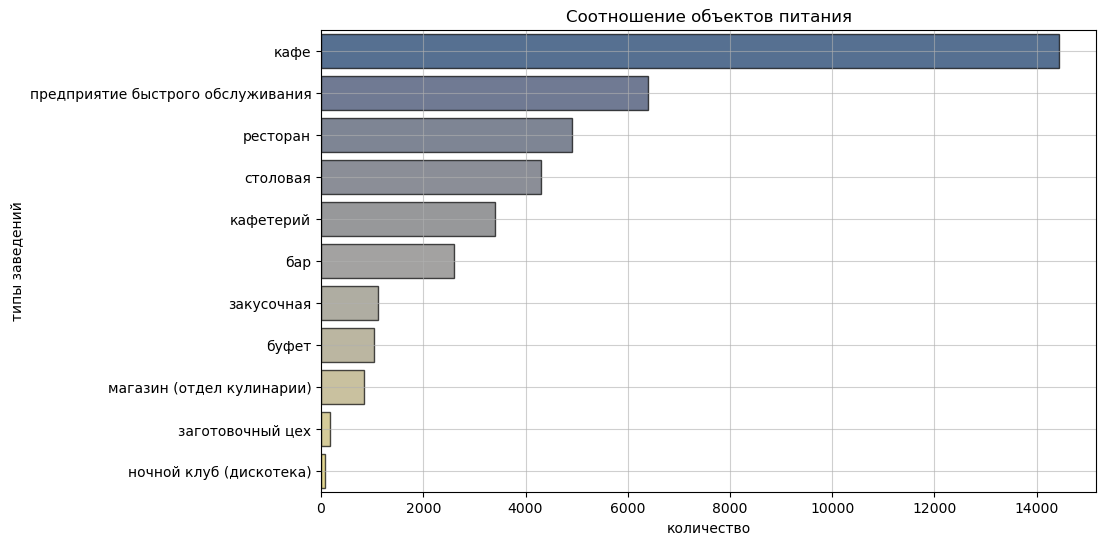

In [14]:
plt.figure(figsize=(10,6))
ax=sns.barplot(data=new_data,x='count',y='TypeObject',hue='TypeObject',palette="cividis",alpha=0.7,edgecolor='black')
ax.set_title('Соотношение объектов питания')
ax.set_xlabel('количество')
ax.set_ylabel('типы заведений')
plt.grid(alpha=0.6)
plt.show()

In [ ]:
#по графику видно что кол-во кафе отличается существенно от кол-ва других заведений  и составляют 36.72% от общего кол-во 
#заведений в городе, меньше всего таких объектов как ночной клуб и заготовочный цех

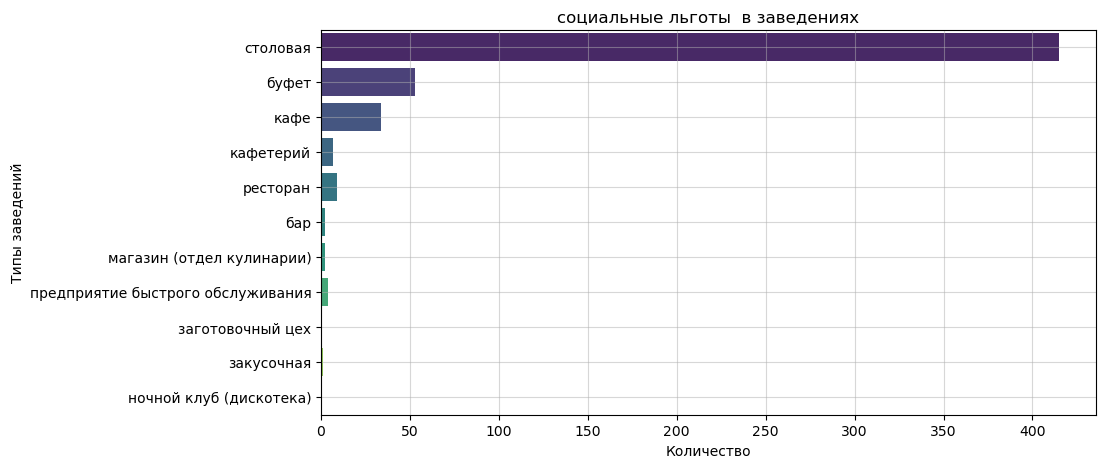

In [15]:
#анализ социальных льгот в каждом из типов заведений
plt.figure(figsize=(10,5))
item=DF.groupby('TypeObject').agg({'ID':'count','SocialPrivileges':'sum'}).reset_index()
item.rename(columns={'ID':'total_count','SocialPrivileges':'count_SocialPrivileges'},inplace=True)
item['percent']=round(item['count_SocialPrivileges']/sum(item['total_count'])*100,2)
item=item.sort_values(by='percent',ascending=False)

ax = sns.barplot(x="count_SocialPrivileges", y="TypeObject",hue='TypeObject',data=item,alpha=1,palette='viridis')
ax.set_ylabel('Типы заведений')
ax.set_xlabel('Количество')
plt.title('социальные льготы  в заведениях')
plt.grid(alpha=0.5)
plt.show()

In [22]:
item

,TypeObject,total_count,count_SocialPrivileges,percent
10,столовая,4299,415,1.06
1,буфет,1036,53,0.13
4,кафе,14438,34,0.09
5,кафетерий,3394,7,0.02
9,ресторан,4910,9,0.02
0,бар,2606,2,0.01
6,магазин (отдел кулинарии),849,2,0.01
8,предприятие быстрого обслуживания,6392,4,0.01
2,заготовочный цех,183,0,0.00
3,закусочная,1122,1,0.00


In [138]:
#по графику видно что социальных льготы больше всего в заведения типа столовых,это можно объяснить присутствием 
#гос.учреждений в этом типе заведений так же льготы получают заведения типа буфет и кафе.
#Рассмотрим какие именно заведения типа столовых получают социальные льготы

In [16]:
def func(DF:pd.DataFrame):
    return DF['Name'].apply(lambda x:any(word in x for word in ['школа','лицей','гимназ.','сош','колледж','гбоу','шк',
                                                               'при'])).sum()

In [17]:
data=DF.query('TypeObject== "столовая" and  SocialPrivileges == "Да" ').reset_index()
count_school1=func(data)
count_school2=func(DF.query('TypeObject== "столовая" and  SocialPrivileges == "Нет"  ').reset_index())
DF_school=pd.DataFrame({'count_SocialPrivileges':[count_school1,count_school2],
                'SocialPrivileges':[True,False]})#школы которые получают и не получают социальные льготы
DF_school

df_SP=pd.DataFrame({'count_SocialPrivileges':[count_school1,(len(data)-count_school1)],
                   'TypeObject':['столовая при учебном заведении','другое']
                   })

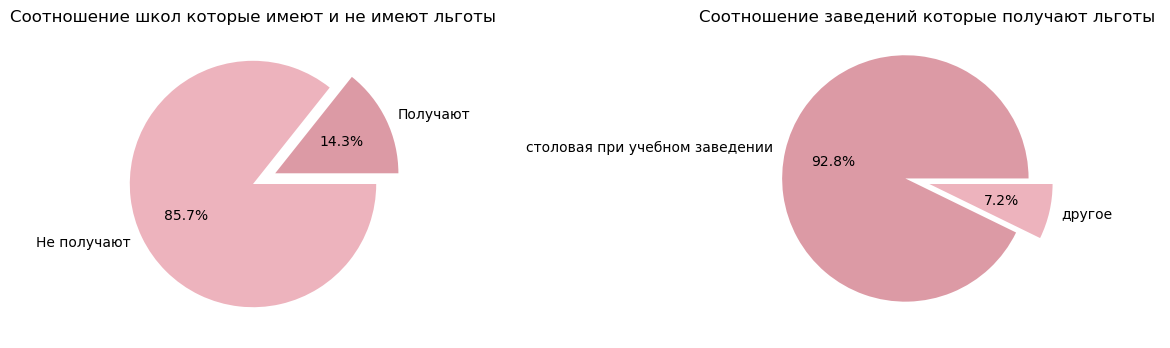

In [18]:
#соотношение школ имеющие и не имеющие социальные льготы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
# sns.set_style("viridis")
ax1.pie(DF_school['count_SocialPrivileges'],
        labels=DF_school['SocialPrivileges'].map({'Да':'Получают','Нет':'Не получают'}),
        colors=['#DC9AA5', '#EDB3BD'],
        explode=[0.2,0],
        autopct='%1.1f%%')
ax1.set_title('Соотношение школ которые имеют и не имеют льготы')

ax2.pie(df_SP['count_SocialPrivileges'],
        labels=df_SP['TypeObject'],
        colors=['#DC9AA5', '#EDB3BD'],
        explode=[0.2,0],
        autopct='%1.1f%%')
ax2.set_title('Соотношение заведений которые получают льготы ')


plt.show()

In [157]:
#видим что лишь небольшая часть школ получает социальные льготы,а именно 14,3%
#но и из всех заведений которые относятся к типу столовых школы занимают 92,8% от всех получаемых льгот в этой нише

In [ ]:
#рассмотрим сетевые и несетевые заведения

In [19]:
new_data=DF.groupby('IsNetObject').agg(count=('ID','count')).reset_index()

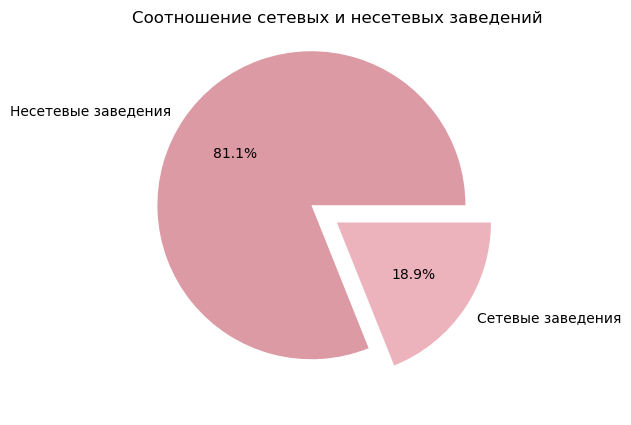

In [20]:
plt.figure(figsize=(10,5))
# sns.
plt.pie(new_data['count'],
        labels=new_data['IsNetObject'].map({'Да':'Сетевые заведения', 'Нет':'Несетевые заведения'}),
        explode=[0.2,0],
        colors=['#DC9AA5', '#EDB3BD'],
        autopct='%1.1f%%'
       )
plt.title('Соотношение сетевых и несетевых заведений')
plt.show()

In [ ]:
#видим,что в гороед преобладают несетевые заведения и составляют 81,1%
#рассмотрим в разрезе сколько несетевых и несетевых заведений в каждом из типов заведений

In [152]:
DF

,global_id,ID,Name,IsNetObject,TypeObject,AdmArea,District,Address,PublicPhone,SeatsCount,SocialPrivileges,geoData
0,637377571,000021304,рахимкулова т.х.,False,буфет,Северо-Восточный административный округ,Бибирево,Алтуфьевское шоссе дом 102Б,"[{'global_id': 48646, 'is_deleted': 0, 'Public...",20,False,POINT (37.59132052872169 55.90406171774882)
1,637379209,000021065,буфет при астраханских банях,False,буфет,Центральный административный округ,Мещанский,Астраханский переулок дом 5/9,"[{'global_id': 48694, 'is_deleted': 0, 'Public...",3,False,POINT (37.63957789928531 55.77888133760811)
2,637379268,000021483,буфет шк.104,False,буфет,Юго-Западный административный округ,Академический,улица Ивана Бабушкина дом 15 корпус 1-2,"[{'global_id': 48697, 'is_deleted': 0, 'Public...",80,False,POINT (37.56309022589957 55.68438723959252)
3,637380390,000028880,школа 1186,False,буфет,Юго-Восточный административный округ,Люблино,Белореченская улица дом 17,"[{'global_id': 48729, 'is_deleted': 0, 'Public...",200,False,POINT (37.767044015525684 55.67266450265205)
4,637381676,000028608,комбинат питания мгту им.н.э.баумана,False,буфет,Центральный административный округ,Басманный,Бригадирский переулок дом 3-5,"[{'global_id': 48767, 'is_deleted': 0, 'Public...",34,False,POINT (37.67960922494895 55.765454552970844)
...,...,...,...,...,...,...,...,...,...,...,...,...
39309,2753461780,00485259,соседи,False,кафетерий,Южный административный округ,Орехово-Борисово Северное,внутригородская территория муниципальный окр...,"[{'is_deleted': 0, 'PublicPhone': '(903) 509-8...",6,False,POINT (37.696757661169215 55.61258556792658)
39310,2753461784,00485196,french bakery,True,кафетерий,Центральный административный округ,Пресненский,внутригородская территория муниципальный окр...,"[{'is_deleted': 0, 'PublicPhone': 'нет телефон...",48,False,POINT (37.53947066472399 55.74901957065029)
39311,2753461915,00485072,мистер кейтеринг,False,заготовочный цех,Восточный административный округ,Гольяново,внутригородская территория муниципальный окр...,"[{'is_deleted': 0, 'PublicPhone': '(926) 210-0...",0,False,POINT (37.75825446562614 55.811377368556045)
39312,2753461917,00485544,школьник-юз,False,заготовочный цех,Южный административный округ,Чертаново Северное,внутригородская территория муниципальный окр...,"[{'is_deleted': 0, 'PublicPhone': '(929) 623-0...",0,False,POINT (37.62133383707825 55.63082523597251)


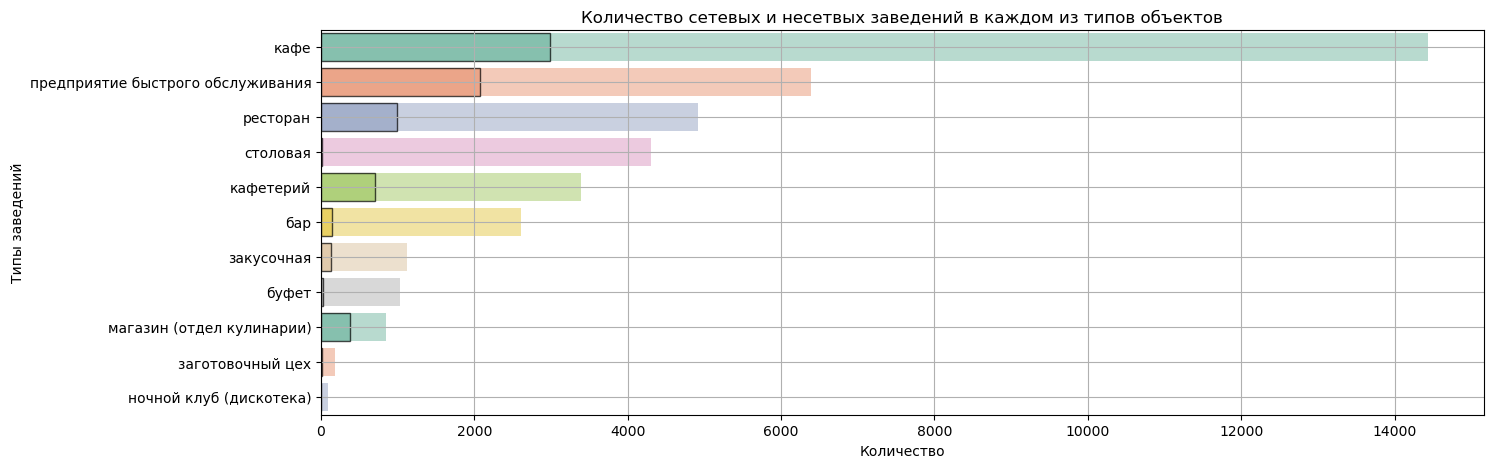

In [30]:
data=DF.groupby('TypeObject').agg(all_count=('Name','count'),net_count=('IsNetObject','sum')).reset_index().sort_values(by='all_count',ascending=False)
plt.figure(figsize=(15,5))
sns.barplot(data=data,y=data['TypeObject'],
            x=data['all_count'],
            hue=data['TypeObject'],
            palette=sns.color_palette('Set2', n_colors=11),
           alpha=0.5)

sns.barplot(data=data,y=data['TypeObject'],
            x=data['net_count'],
            hue=data['TypeObject'],
            palette=sns.color_palette('Set2', n_colors=11),
           alpha=0.7,
           edgecolor='black')
plt.title('Количество сетевых и несетвых заведений в каждом из типов объектов')
plt.xlabel('Количество')
plt.ylabel('Типы заведений')
plt.grid()
plt.show()

In [31]:
data['percent_in_type']=round(data['net_count']/data['all_count']*100,2)
data['percent_all']=round(data['net_count']/sum(data['all_count'])*100,2)
data.sort_values(by=['percent_all','percent_in_type'],ascending=False)

,TypeObject,all_count,net_count,percent_in_type,percent_all
4,кафе,14438,2982,20.65,7.59
8,предприятие быстрого обслуживания,6392,2068,32.35,5.26
9,ресторан,4910,997,20.31,2.54
5,кафетерий,3394,702,20.68,1.79
6,магазин (отдел кулинарии),849,381,44.88,0.97
0,бар,2606,138,5.30,0.35
3,закусочная,1122,127,11.32,0.32
1,буфет,1036,26,2.51,0.07
10,столовая,4299,14,0.33,0.04
2,заготовочный цех,183,8,4.37,0.02


In [ ]:
#как видно по графику больше всего сетевых заведений у объектов типа кафе , предприятий быстрого обслуживания
# и ресторанов,они составляют 20.65% 32.35% 20.31% от своих типов заведений и 7.59% 5.26% 2.54% от всех заведений в городе
#так же по таблице видно что в типах заведений как магазин (отдел кулинарии) чаще наблюдается тенденция к созданию сети ,
#сети в этом типе заведений составляют 44.88% от всех заведений в этой сети что больше чем в других сетях

#рассмотрим самые крупные сети в заведениях типа  кафе , предприятий быстрого обслуживания и ресторанов

In [33]:
result=DF.query(" TypeObject in ['кафе','предприятие быстрого обслуживания','ресторан'] ").\
    groupby(['TypeObject','Name']).agg(count=('ID','count')).reset_index().sort_values(by='count',ascending=False)
result.head(50)

,TypeObject,Name,count
10458,предприятие быстрого обслуживания,шаурма,500
3669,кафе,кафе,337
9050,предприятие быстрого обслуживания,вкусно и точка,326
7937,кафе,шоколадница,295
8442,предприятие быстрого обслуживания,kfc,289
8987,предприятие быстрого обслуживания,бургер кинг,253
9619,предприятие быстрого обслуживания,крошка картошка,160
10281,предприятие быстрого обслуживания,теремок,151
3294,кафе,додо пицца,142
2844,кафе,буханка,118


In [231]:
#как видим в Москве чаще всего сети образуют такие объекты как шаурма,шоколадница и тд по таблице
#что чаще всего  мы и видим на улицах города 
#так же видим что некоторые точки сети таких как kfc вкусно и точка имеют тип завдения ресторан , но большая часть все равно представляет 
# такой тип как предприятие быстрого обслуживания

In [ ]:
#анализ расположения заведений

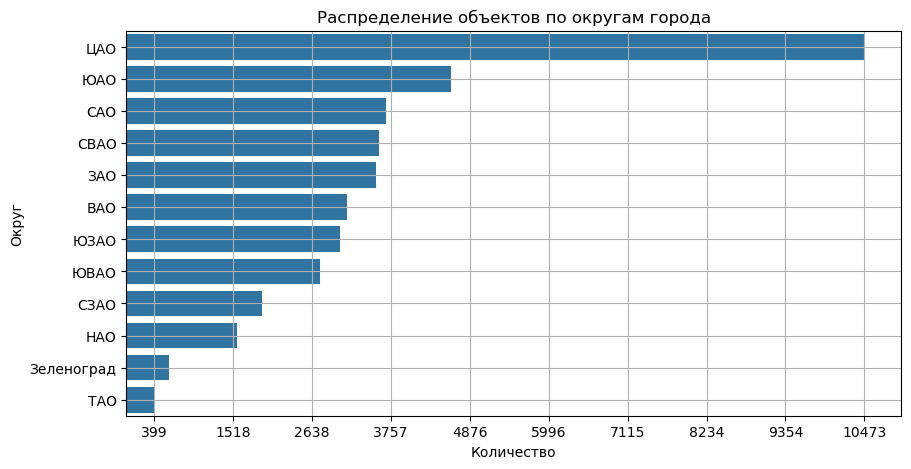

In [34]:
admarea_map = {
    'Центральный административный округ': 'ЦАО',
    'Южный административный округ': 'ЮАО',
    'Северный административный округ': 'САО',
    'Северо-Восточный административный округ': 'СВАО',
    'Западный административный округ': 'ЗАО',
    'Восточный административный округ': 'ВАО',
    'Юго-Западный административный округ': 'ЮЗАО',
    'Юго-Восточный административный округ': 'ЮВАО',
    'Северо-Западный административный округ': 'СЗАО',
    'Новомосковский административный округ': 'НАО',
    'Зеленоградский административный округ': 'Зеленоград',
    'Троицкий административный округ': 'ТАО'
}

data=DF.groupby('AdmArea').agg(count=('ID','count')).reset_index().sort_values(by='count',ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='count',
            y=data['AdmArea'].map(admarea_map),
           errorbar=None,
            data=data)
plt.xticks(np.linspace(min(data['count']),max(data['count']),10))
plt.xlabel('Количество')
plt.ylabel('Округ')
plt.grid(axis='both')
plt.title('Распределение объектов по округам города')
plt.show()

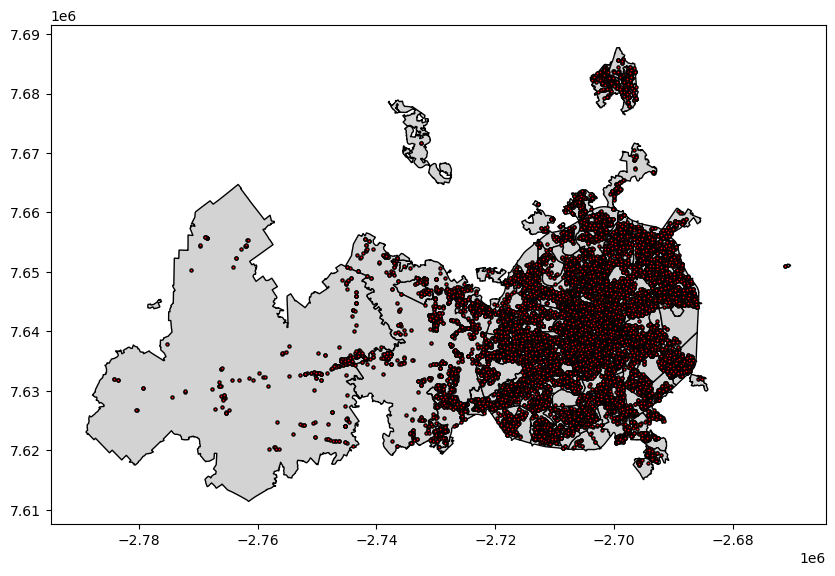

In [36]:
# Считываем базовую карту Москвы
DF_geo = gpd.read_file('Москва_Moscow.geojson')
DF_geo = DF_geo.to_crs('EPSG:32646')
gdf_cities = gpd.GeoDataFrame(DF, geometry=DF['geoData'],crs="EPSG:4326")
gdf_cities = gdf_cities.to_crs(DF_geo.crs)
fig, ax = plt.subplots(figsize=(10, 10))
DF_geo.plot(ax=ax, color='lightgray', edgecolor='black')
gdf_cities.plot(ax=ax, marker='.', color='red', markersize=20, label='Города',edgecolor='black')

# plt.legend()
plt.show()


In [37]:
#так как по этой карте сложно ориентироваться,построим карты для каждого округа для этого поделим Москву на округи
DF_geo

,district,geometry
0,район Богородское,"POLYGON ((-2692590.811 7644272.298, -2692599.1..."
1,район Вешняки,"POLYGON ((-2698234.398 7630591.247, -2698235.3..."
2,район Восточное Измайлово,"POLYGON ((-2691105.335 7633608.732, -2691107.3..."
3,район Восточный,"MULTIPOLYGON (((-2687067.516 7632766.899, -268..."
4,район Гольяново,"POLYGON ((-2692017.716 7637778.671, -2692209.4..."
...,...,...
122,район Чертаново Центральное,"POLYGON ((-2719389.749 7631168.019, -2719419.7..."
123,район Чертаново Южное,"POLYGON ((-2721862.205 7628812.836, -2721743.9..."
124,район Старое Крюково,"POLYGON ((-2701212.402 7682603.511, -2701219.9..."
125,Новомосковский административный округ,"POLYGON ((-2743006.19 7656248.987, -2742986.25..."


In [38]:
district_to_okrug = {
    # Центральный административный округ (ЦАО)
    "Арбат": "ЦАО", "Басманный": "ЦАО", "Замоскворечье": "ЦАО", "Красносельский": "ЦАО",
    "Мещанский": "ЦАО", "Пресненский": "ЦАО", "Таганский": "ЦАО", "Тверской": "ЦАО",
    "Хамовники": "ЦАО", "Якиманка": "ЦАО",

    # Северный административный округ (САО)
    "Аэропорт": "САО", "Беговой": "САО", "Бескудниковский": "САО", "Войковский": "САО",
    "Восточное Дегунино": "САО", "Головинский": "САО", "Дмитровский": "САО",
    "Западное Дегунино": "САО", "Коптево": "САО", "Левобережный": "САО",
    "Молжаниновский": "САО", "Савеловский": "САО", "Сокол": "САО",
    "Тимирязевский": "САО", "Ховрино": "САО","Хорошевский":"САО",

    # Северо-Восточный административный округ (СВАО)
    "Алексеевский": "СВАО", "Алтуфьевский": "СВАО", "Бабушкинский": "СВАО",
    "Бибирево": "СВАО", "Бутырский": "СВАО", "Лианозово": "СВАО",
    "Лосиноостровский": "СВАО", "Марфино": "СВАО", "Марьина роща": "СВАО",
    "Останкинский": "СВАО", "Отрадное": "СВАО", "Ростокино": "СВАО",
    "Свиблово": "СВАО", "Северное Медведково": "СВАО", "Южное Медведково": "СВАО",
    "Ярославский": "СВАО",

    # Восточный административный округ (ВАО)
    "Богородское": "ВАО", "Вешняки": "ВАО", "Восточный": "ВАО", "Гольяново": "ВАО",
    "Ивановское": "ВАО", "Восточное Измайлово": "ВАО", "Косино-Ухтомский": "ВАО",
    "Метрогородок": "ВАО", "Новогиреево": "ВАО", "Новокосино": "ВАО",
    "Перово": "ВАО", "Преображенское": "ВАО", "Соколиная Гора": "ВАО",
    "Сокольники": "ВАО","Северное Измайлово":"ВАО", 'Измайлово':"ВАО",
    "Соколиная гора" : "ВАО",

    # Юго-Восточный административный округ (ЮВАО)
    "Выхино-Жулебино": "ЮВАО", "Капотня": "ЮВАО", "Кузьминки": "ЮВАО",
    "Лефортово": "ЮВАО", "Люблино": "ЮВАО", "Марьино": "ЮВАО", "Некрасовка": "ЮВАО",
    "Нижегородский": "ЮВАО", "Печатники": "ЮВАО", "Рязанский": "ЮВАО",
    "Текстильщики": "ЮВАО",'Южнопортовый':'ЮВАО',

    # Южный административный округ (ЮАО)
    "Бирюлёво Восточное": "ЮАО", "Бирюлево Западное": "ЮАО", "Братеево": "ЮАО",
    "Даниловский": "ЮАО", "Донской": "ЮАО", "Зябликово": "ЮАО", "Москворечье-Сабурово": "ЮАО",
    "Нагатино-Садовники": "ЮАО", "Нагатинский Затон": "ЮАО", "Нагорный": "ЮАО",
    "Орехово-Борисово Северное": "ЮАО", "Орехово-Борисово Южное": "ЮАО",
    "Царицыно": "ЮАО", "Чертаново Северное": "ЮАО", "Чертаново Центральное": "ЮАО",
    "Чертаново Южное": "ЮАО","Нагатинский затон":'ЮАО','Бирюлево Восточное':"ЮАО",

    # Юго-Западный административный округ (ЮЗАО)
    "Академический": "ЮЗАО", "Гагаринский": "ЮЗАО", "Зюзино": "ЮЗАО",
    "Коньково": "ЮЗАО", "Котловка": "ЮЗАО", "Ломоносовский": "ЮЗАО",
    "Обручевский": "ЮЗАО", "Северное Бутово": "ЮЗАО", "Тёплый Стан": "ЮЗАО",
    "Черёмушки": "ЮЗАО", "Южное Бутово": "ЮЗАО", "Ясенево": "ЮЗАО",
    'Теплый Стан' :"ЮЗАО" , 'Черемушки':'ЮЗАО',
    
    # Западный административный округ (ЗАО)
    "Внуково": "ЗАО", "Дорогомилово": "ЗАО", "Крылатское": "ЗАО",
    "Кунцево": "ЗАО", "Можайский": "ЗАО", "Ново-Переделкино": "ЗАО",
    "Очаково-Матвеевское": "ЗАО", "Проспект Вернадского": "ЗАО", "Раменки": "ЗАО",
    "Солнцево": "ЗАО", "Филёвский Парк": "ЗАО", "Фили-Давыдково": "ЗАО",
    'Тропарево-Никулино':"ЗАО" , 'Филевский парк':"ЗАО",

    # Северо-Западный административный округ (СЗАО)
    "Куркино": "СЗАО", "Митино": "СЗАО", "Покровское-Стрешнево": "СЗАО",
    "Северное Тушино": "СЗАО", "Строгино": "СЗАО", "Хорошёво-Мнёвники": "СЗАО",
    "Щукино": "СЗАО", "Южное Тушино": "СЗАО",'Северный':'СЗАО',
    'Хорошево-Мневники' :'СЗАО',

    # Новомосковский административный округ (НАО)
    "Воскресенское": 'НАО' , "Десёновское": "НАО", "Кокошкино": "НАО",
    "Марушкинское": "НАО", "Московский": "НАО", "Рязановское": "НАО",
    "Сосенское": "НАО", "Филимонковское": "НАО", "Щербинка": "НАО",

    # Троицкий административный округ (ТАО)
    "Вороновское": "ТАО", "Киевский": "ТАО", "Клёновское": "ТАО",
    "Краснопахорское": "ТАО", "Михайлово-Ярцевское": "ТАО", "Новофёдоровское": "ТАО",
    "Первомайское": "ТАО", "Роговское": "ТАО", "Троицк": "ТАО",
    "Троицкий административный округ" : "ТАО",

    # Зеленоградский административный округ (Зеленоград)
    "Крюково": "Зеленоград", "Матушкино": "Зеленоград", "Савёлки": "Зеленоград",
    "Силино": "Зеленоград", "Старое Крюково": "Зеленоград",'Савелки':'Зеленоград',

    #Новомосковский административный округ (НАО)

    'Новомосковский административный округ':'НАО'
}


In [39]:
DF_geo['district']=DF_geo['district'].str.replace('район','').str.strip()
DF_geo["okrug"] = DF_geo['district'].map(district_to_okrug)
# Проверяем, нет ли районов, которые не попали в словарь
DF_geo[DF_geo["okrug"].isna()]['district'].unique()
DF_geo

,district,geometry,okrug
0,Богородское,"POLYGON ((-2692590.811 7644272.298, -2692599.1...",ВАО
1,Вешняки,"POLYGON ((-2698234.398 7630591.247, -2698235.3...",ВАО
2,Восточное Измайлово,"POLYGON ((-2691105.335 7633608.732, -2691107.3...",ВАО
3,Восточный,"MULTIPOLYGON (((-2687067.516 7632766.899, -268...",ВАО
4,Гольяново,"POLYGON ((-2692017.716 7637778.671, -2692209.4...",ВАО
...,...,...,...
122,Чертаново Центральное,"POLYGON ((-2719389.749 7631168.019, -2719419.7...",ЮАО
123,Чертаново Южное,"POLYGON ((-2721862.205 7628812.836, -2721743.9...",ЮАО
124,Старое Крюково,"POLYGON ((-2701212.402 7682603.511, -2701219.9...",Зеленоград
125,Новомосковский административный округ,"POLYGON ((-2743006.19 7656248.987, -2742986.25...",НАО


In [40]:
okrugs=['ЦАО', 'САО', 'СВАО', 'ЮВАО', 'ВАО', 'ЗАО', 'СЗАО', 'ЮАО', 'ЮЗАО', 'НАО', 'ТАО', 'Зеленоград']

df_geodict={okrug: DF_geo[DF_geo['okrug'] == okrug] for okrug in okrugs}

In [41]:
DF['District']=DF['District'].astype('string')
DF['District']=DF['District'].str.strip()
DF['okrug']=DF['District'].map(district_to_okrug)

In [42]:
#проверим для всех ли районов нашли округ и оставим только те для которых был найдет округ 
new_DF=DF[~DF['okrug'].isna()]

In [43]:
df_dict={okrug: DF[DF['okrug'] == okrug] for okrug in okrugs}

In [463]:
#рассмотрим каждый из округов подробнее

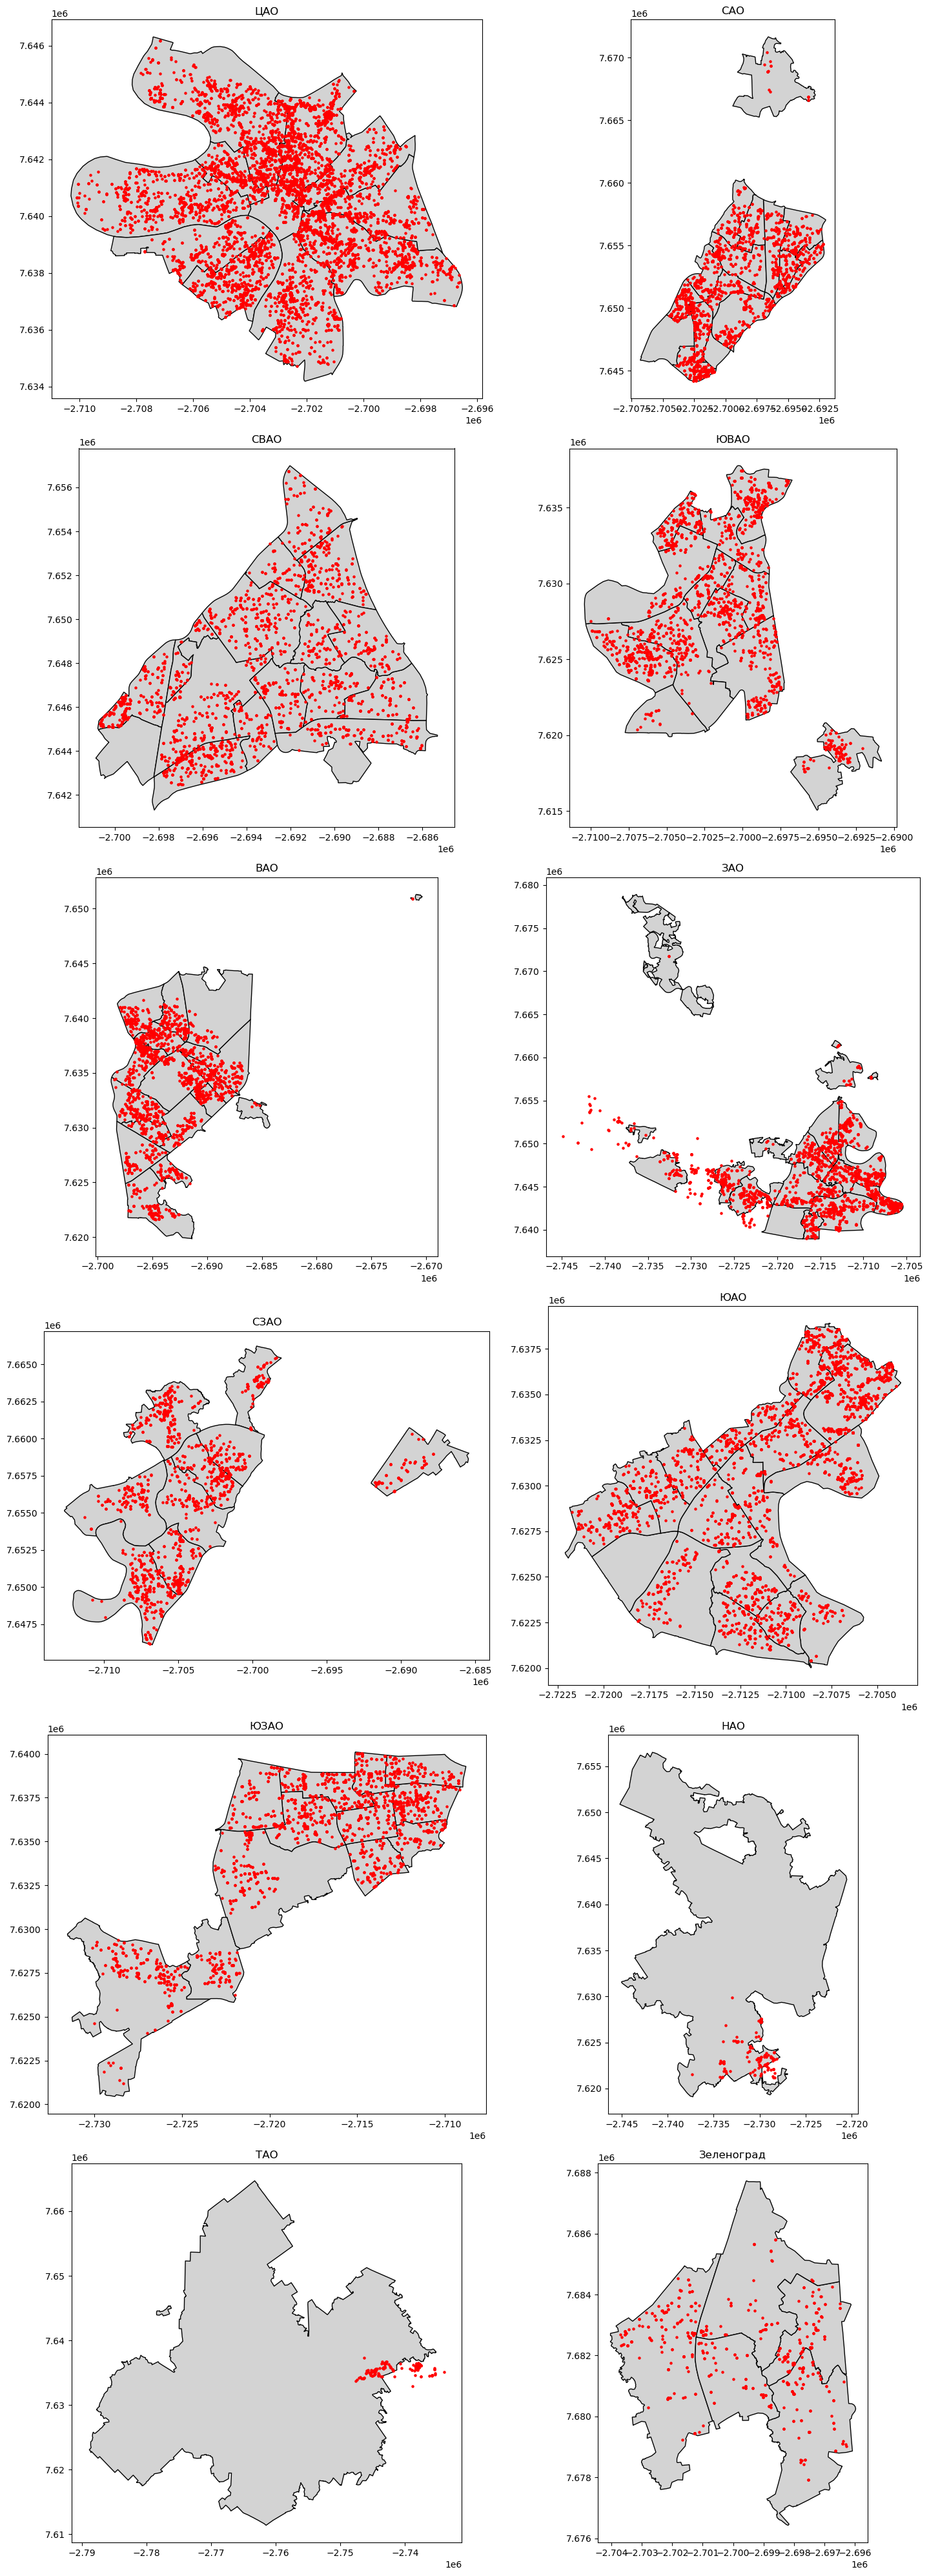

In [44]:
plt.figure(figsize=(15, 40))  # Создаем фигуру один раз

for i, okrug in enumerate(okrugs):
    plt.subplot(6, 2, (i + 1))  # Создаем подграфик
    ax = plt.gca()  # Получаем текущие оси (current axes) для этого подграфика

    # Наносим базовую карту (границы округа)
    df_geodict[okrug].plot(ax=ax, color='lightgray', edgecolor='black')

    gdf_cities = gpd.GeoDataFrame(df_dict[okrug], geometry=df_dict[okrug]['geoData'], crs="EPSG:4326")

    gdf_cities = gdf_cities.to_crs(df_geodict[okrug].crs)

    # Наносим точки на карту
    gdf_cities.plot(ax=ax, marker='.', color='red', markersize=20, label='')  # Убрали label, так как это отдельные графики

    # Настраиваем отображение
    plt.title(okrug) # или ax.set_title(okrug), если хотите явно указать, что титул относится к этому подграфику

plt.tight_layout()
plt.show()


In [67]:
#по графикам видно,что больше всего заведений расположено в округах ЦАО и ЮАО
#посмотрим какие типы заведений встречаются чаще всего в этом округе
data=df_dict['ЦАО'].groupby('TypeObject').agg(count=('ID','count')).reset_index().sort_values(by='count',ascending=False)
data['percent']=data['count']/DF.groupby('TypeObject').agg(count=('ID','count')).reset_index()['count']*100#процент заведений от общего кол-во по городу
data.sort_values(by='percent',ascending=False)

,TypeObject,count,percent
7,ночной клуб (дискотека),50,58.823529
0,бар,1232,47.275518
9,ресторан,2065,42.057026
4,кафе,4707,32.601468
1,буфет,231,22.297297
5,кафетерий,699,20.595168
6,магазин (отдел кулинарии),164,19.316843
10,столовая,616,14.328914
3,закусочная,148,13.190731
8,предприятие быстрого обслуживания,547,8.557572


In [68]:
sum(data['count'])#всего заведений

10473

In [ ]:
#топ 3 по кол-во заведений занимают такие типы объектов  как кафе,рестораны и бар,
# в центре сосредоточены почти 32%,42%,47% кафе ресторанов и баров соответсвенно, так же в центре находится почти 60% ночных клубов 
#столицы.
#А вот такие заведения как буфеты столовые , закусочные,предприятие быстрого обслуживания в центре спросом не пользуются

#много заведений где можно отдохнуть и развеятся 

In [65]:
#рассмотрим более жилые районы 
#ЮАО
data=df_dict['ЮАО'].groupby('TypeObject').agg(count=('ID','count')).reset_index().sort_values(by='count',ascending=False)
data['percent']=data['count']/DF.groupby('TypeObject').agg(count=('ID','count')).reset_index()['count']*100#процент заведений от общего кол-во по городу
data.sort_values(by='percent',ascending=False)

,TypeObject,count,percent
8,предприятие быстрого обслуживания,1125,17.600125
2,заготовочный цех,30,16.393443
10,столовая,577,13.421726
5,кафетерий,390,11.490866
4,кафе,1518,10.513922
6,магазин (отдел кулинарии),84,9.893993
0,бар,236,9.056025
9,ресторан,422,8.594705
3,закусочная,80,7.130125
7,ночной клуб (дискотека),6,7.058824


In [ ]:
#в этом округе так же расположено много кафе,но на 2 и 3 месте по встречаемости находятся такие типы заведений как 
#предприятие быстрого обслуживания и столовая
#что логично ведь ЮАО считается более спальным районом чем ЦАО и практичнее  открыть в этом районе
#заведение в которое люди будут ходить ежедневно , но и наблюдается явный спад по кол-ву заведений 
# к примеру  в этом округе расположено меньше заведений чем в центральном округе заведений типа кафе,хотя площаль этого округа почти в 2 раза
#больше центрального округа(66,18км**2) и составляет 132км**2


In [74]:
#меньше всего заведений встречается в новой москве,зеленограде и ТАО 
#рассмотрим какого типа заведения типичны для этих округов
data=df_dict['НАО'].groupby('TypeObject').agg(count=('ID','count')).reset_index().sort_values(by='count',ascending=False)
data['percent']=data['count']/DF.groupby('TypeObject').agg(count=('ID','count')).reset_index()['count']*100#процент заведений от общего кол-во по городу
data.sort_values(by='percent',ascending=False)

,TypeObject,count,percent
7,ресторан,6,7.058824
3,кафе,74,6.595365
6,предприятие быстрого обслуживания,40,4.711425
2,заготовочный цех,5,2.732240
8,столовая,10,0.156446
5,магазин (отдел кулинарии),4,0.117855
1,буфет,1,0.096525
0,бар,2,0.076746
4,кафетерий,8,0.055409


In [73]:
data=df_dict['ТАО'].groupby('TypeObject').agg(count=('ID','count')).reset_index().sort_values(by='count',ascending=False)
data['percent']=data['count']/DF.groupby('TypeObject').agg(count=('ID','count')).reset_index()['count']*100#процент заведений от общего кол-во по городу
data.sort_values(by='percent',ascending=False)



,TypeObject,count,percent
7,ресторан,6,7.058824
3,кафе,54,4.812834
2,закусочная,8,4.371585
6,предприятие быстрого обслуживания,32,3.769140
0,бар,9,0.345357
1,заготовочный цех,3,0.289575
4,кафетерий,37,0.256268
8,столовая,7,0.109512
5,магазин (отдел кулинарии),2,0.058928


In [75]:
data=df_dict['Зеленоград'].groupby('TypeObject').agg(count=('ID','count')).reset_index().sort_values(by='count',ascending=False)
data['percent']=data['count']/DF.groupby('TypeObject').agg(count=('ID','count')).reset_index()['count']*100#процент заведений от общего кол-во по городу
data.sort_values(by='percent',ascending=False)


,TypeObject,count,percent
2,заготовочный цех,7,3.825137
10,столовая,155,3.605490
7,ночной клуб (дискотека),3,3.529412
6,магазин (отдел кулинарии),18,2.120141
5,кафетерий,71,2.091927
0,бар,49,1.880276
8,предприятие быстрого обслуживания,100,1.564456
4,кафе,141,0.976590
1,буфет,9,0.868726
3,закусочная,9,0.802139


In [ ]:
# как и в случаи с ЮАО для этих районов свойственны такие типы заведений как столовая,кафе и предприятие быстрого обслуживания
#но в меньших кол-вах чем в том же ЮАО
#что можно объяснить тем что эти округи не сильно популярны для покупки и продолжают развививатьс ,
#так же эти районы выбирают обычные люди для которых намного практичнее сходить не в очень дорогое место перекусить 
#во время рабочей недели